# Интерпретация

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

## Подготовка данных и моделей

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Загрузка данных 
data = pd.read_csv("data_unreg.csv")

# Признаки
num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data.drop(columns=["price_target"])
y = data["price_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline-модели
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])
cat_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

lin_model = Pipeline([("preprocessor", preprocessor),
                       ("model", LinearRegression())])
gb_model  = Pipeline([("preprocessor", preprocessor),
                       ("model", GradientBoostingRegressor(max_depth=5, random_state=42))])

lin_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Модели обучены")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")


Модели обучены
  Train: (23924, 82)  |  Test: (5981, 82)


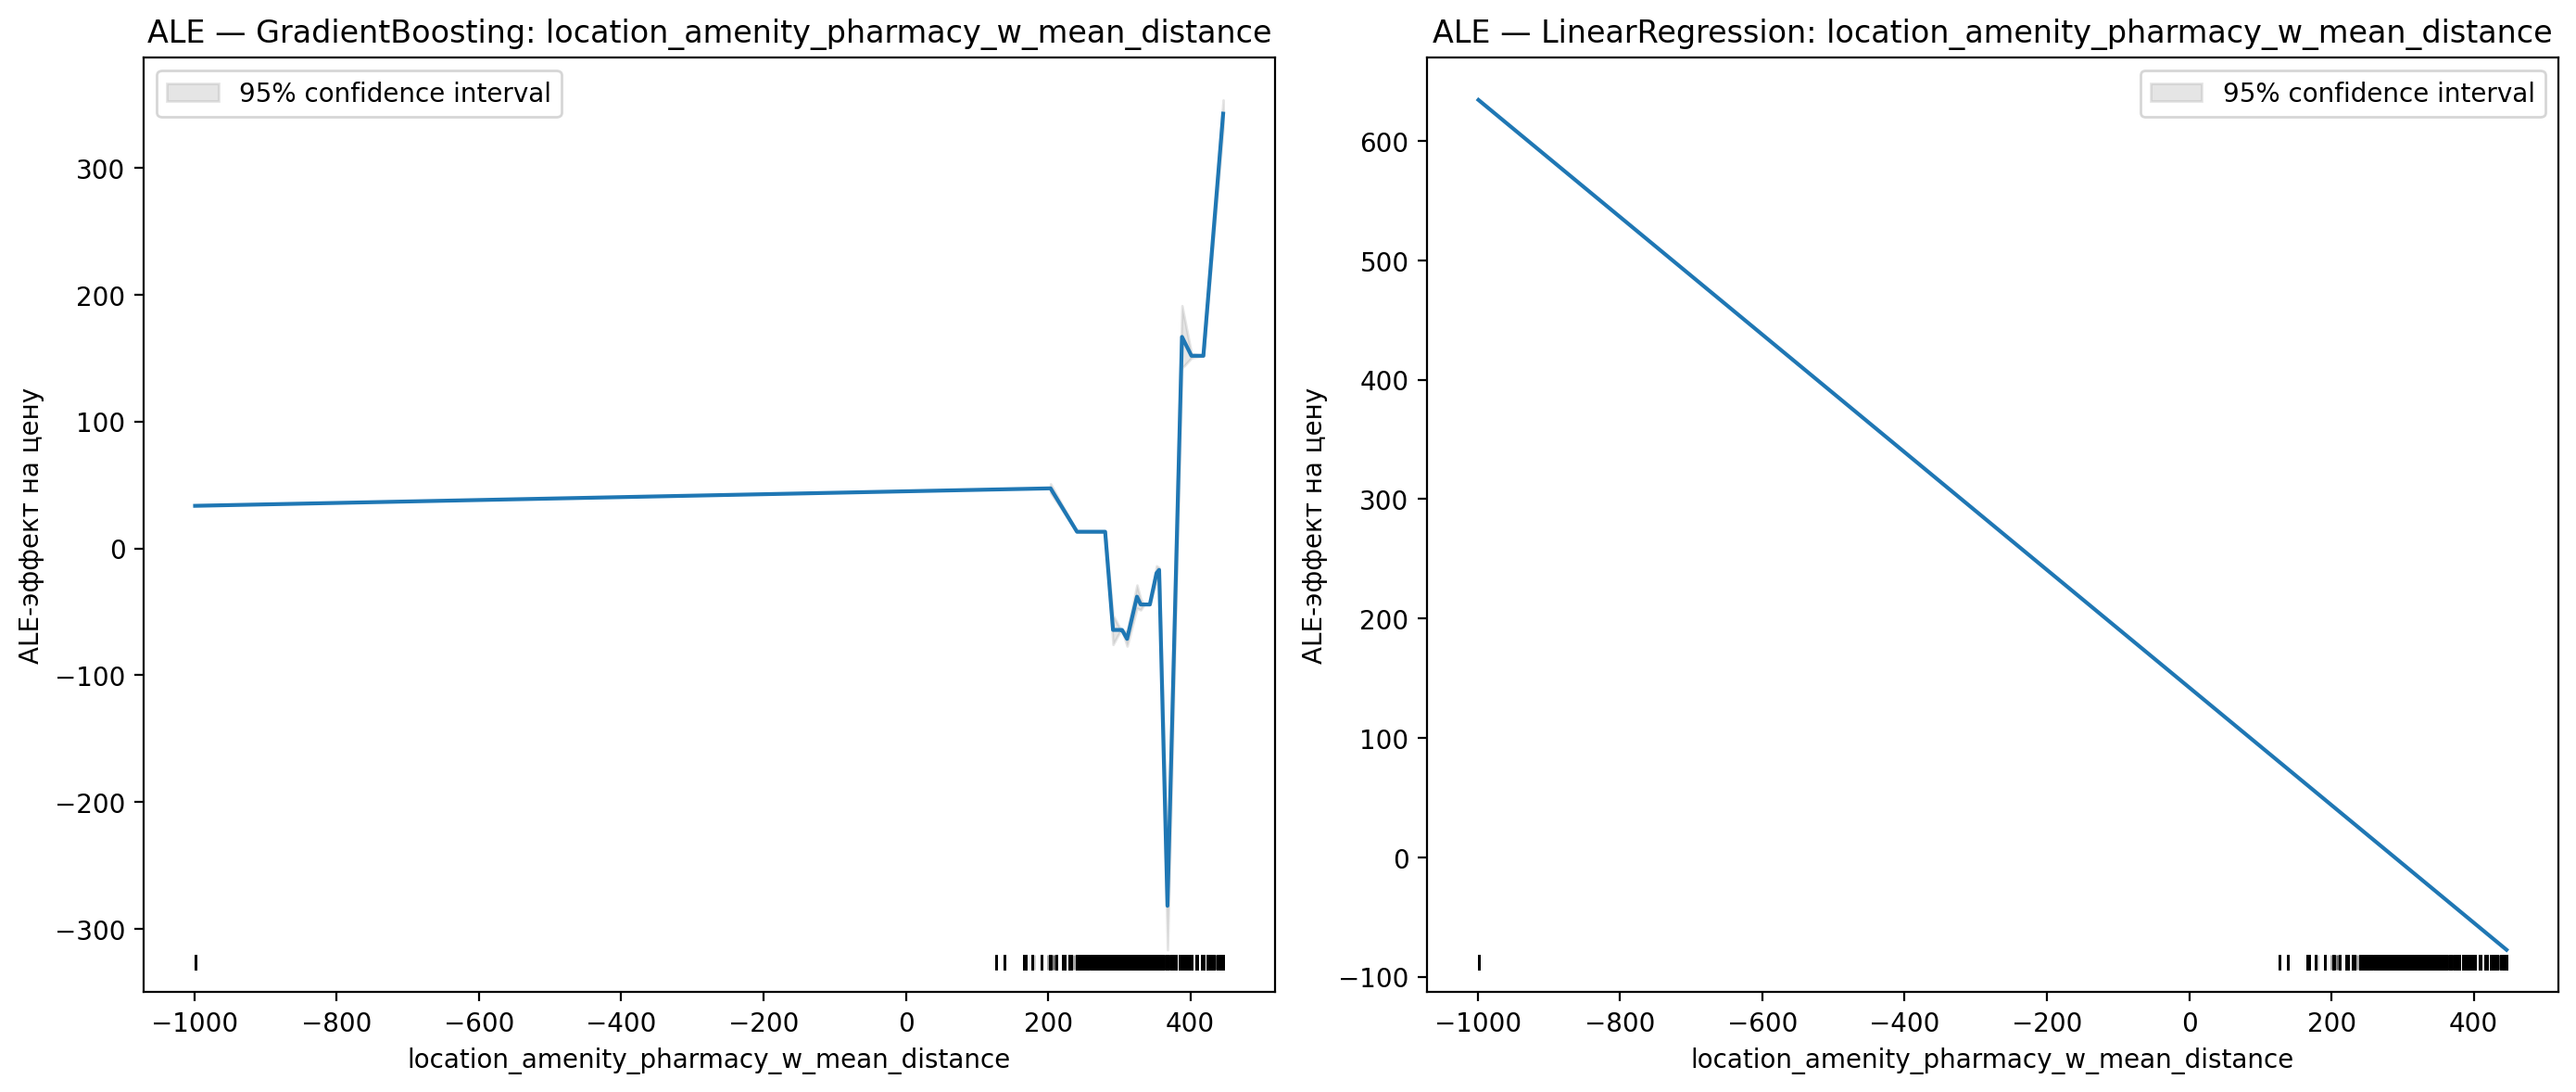

In [2]:
from PyALE import ale

# Используем вещественный числовой признак.
# feature_type="continuous" необходимо указывать явно для числовых признаков:
# если в столбце мало уникальных значений, PyALE автоматически переключается
# на дискретный режим, где возможен IndexError при выходе за границу групп.
ale_feature = "location_amenity_pharmacy_w_mean_distance"
X_train_ale = X_train.dropna(subset=[ale_feature]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name in zip(axes,
                            [gb_model,  lin_model],
                            ["GradientBoosting", "LinearRegression"]):
    ale(
        X=X_train_ale,
        model=model,
        feature=[ale_feature],
        feature_type="continuous", 
        grid_size=20,
        include_CI=True,
        C=0.95,
        plot=True,
        fig=fig,
        ax=ax,
    )
    ax.set_title(f"ALE — {name}: {ale_feature}")
    ax.set_xlabel(ale_feature)
    ax.set_ylabel("ALE-эффект на цену")

plt.tight_layout()
plt.show()

### Анализ

**Доверительные интервалы:**
- При `grid_size=20` большинство бинов содержат достаточно наблюдений,
  и ДИ получаются относительно узкими.

**Почему ДИ различны для двух моделей:**
- У *LinearRegression* ALE-кривая линейна, ДИ практически незаметны:
  модель предсказывает одинаково уверенно во всём диапазоне.
- У *GradientBoosting* кривая кусочно-постоянна (ансамбль деревьев), а ДИ
  шире в областях, где мало обучающих объектов - там выше разброс локальных
  эффектов и меньше данных для их оценки.
